In [1]:
# Load libraries
import requests
import pyreadr
import pandas as pd

# GitHub raw file URL
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

# Download file
response = requests.get(url)

# Save locally
with open("../raw_data/dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# Read RData file
result = pyreadr.read_r("../raw_data/dt_simulated_weekly.RData")

# Show objects
print(result.keys())

# Extract dataset
df = result["dt_simulated_weekly"]

# Overview
print(df.shape)
print(df.columns.tolist())

# Preview
df.head()

odict_keys(['dt_simulated_weekly'])
(208, 12)
['DATE', 'revenue', 'tv_S', 'ooh_S', 'print_S', 'facebook_I', 'search_clicks_P', 'search_S', 'competitor_sales_B', 'facebook_S', 'events', 'newsletter']


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


In [3]:
# Define target
target = "revenue"

# Define media channels
media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S"
]

# Define control variables
control_cols = [
    "competitor_sales_B",
    "newsletter"
]

In [4]:
# Convert date column
df["DATE"] = pd.to_datetime(df["DATE"])

# Sort by date
df = df.sort_values("DATE")

In [5]:
# Basic dataset info
print(df.shape)

# Show first rows
df.head()

(208, 12)


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


In [6]:
# Check missing values
df.isnull().sum()

DATE                  0
revenue               0
tv_S                  0
ooh_S                 0
print_S               0
facebook_I            0
search_clicks_P       0
search_S              0
competitor_sales_B    0
facebook_S            0
events                0
newsletter            0
dtype: int64

No missing values are present in the dataset.
Therefore, no imputation or missing-data treatment was required.

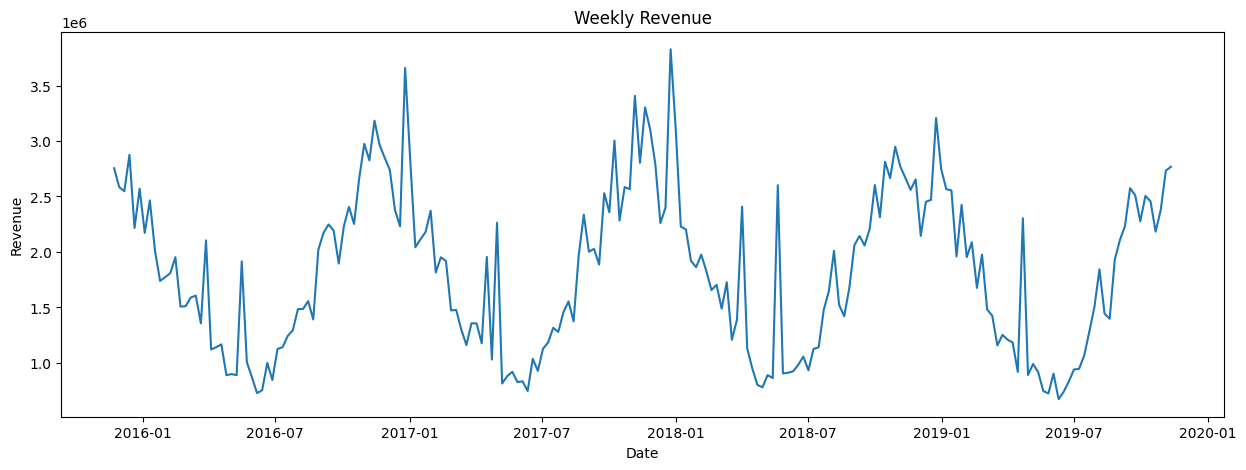

In [7]:
import matplotlib.pyplot as plt

# Plot revenue over time
plt.figure(figsize=(15,5))

plt.plot(df["DATE"], df[target])

plt.title("Weekly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

The revenue series exhibits strong temporal structure with visible
seasonal fluctuations and repeated yearly patterns. Several sharp
spikes are also observable, indicating periods of unusually high
sales activity. These dynamics motivate the use of time-aware
Marketing Mix Modeling techniques with lagged and nonlinear effects.


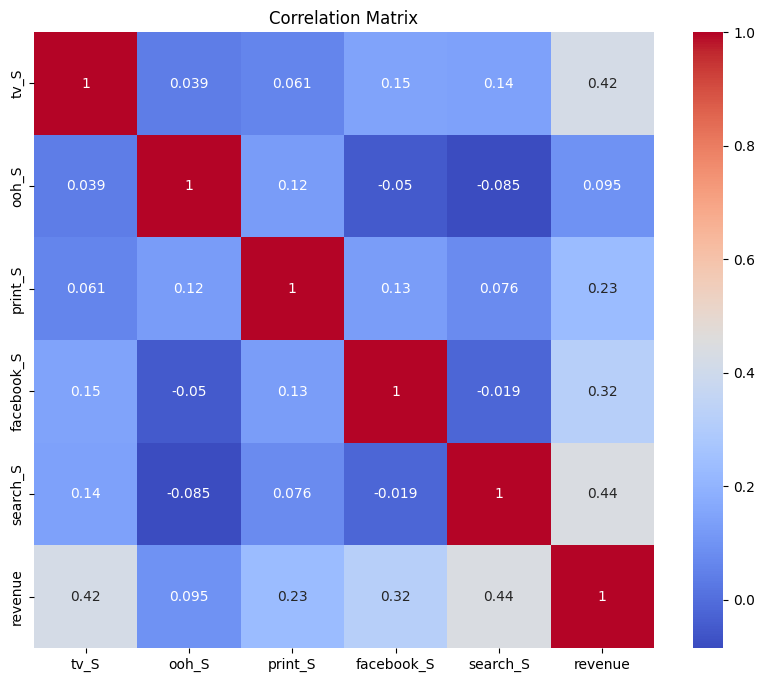

In [8]:
import seaborn as sns

# Correlation matrix
corr = df[media_cols + [target]].corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The correlation structure indicates relatively low multicollinearity
between media channels, which is favorable for parameter
identification in Bayesian Marketing Mix Models. Revenue exhibits
moderate positive correlations with search and TV spend, suggesting
these channels may contribute substantially to sales variation.
The comparatively clean correlation structure of the simulated dataset
may simplify attribution relative to real-world MMM applications,
where media channels are often highly collinear.

In [9]:
# Store lag correlations
lag_corrs = {}

# Calculate lagged correlations
for lag in range(0, 8):
    lag_corrs[lag] = (
        df[target]
        .corr(df["tv_S"].shift(lag))
    )

print(lag_corrs)

{0: np.float64(0.4198694240823361), 1: np.float64(0.30111040816542445), 2: np.float64(0.35043974430989017), 3: np.float64(0.2713852268493796), 4: np.float64(0.3335626831350803), 5: np.float64(0.29489966854859473), 6: np.float64(0.32161287591423265), 7: np.float64(0.2288221556643287)}


Lagged correlations between TV spend and revenue remain positive
across multiple weeks, indicating persistent advertising effects over
time. The gradual decay pattern supports the use of geometric
adstock transformations in the Bayesian MMM specification, as media
effects do not appear to dissipate immediately after exposure.

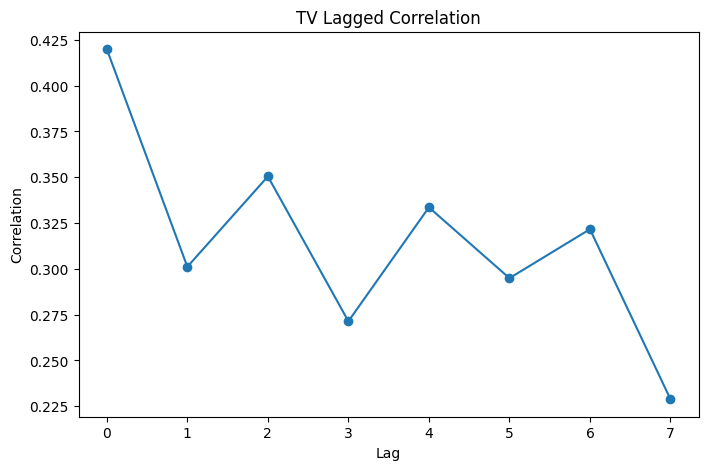

In [10]:
import matplotlib.pyplot as plt

# Plot lagged correlations
plt.figure(figsize=(8,5))

plt.plot(
    list(lag_corrs.keys()),
    list(lag_corrs.values()),
    marker="o"
)

plt.title("TV Lagged Correlation")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.show()

The lagged correlation analysis reveals persistent relationships
between TV spend and revenue across multiple weeks. Although the
correlation gradually weakens, meaningful positive associations remain
observable at higher lags, indicating delayed and persistent media
effects. This behavior supports the use of geometric adstock
transformations in the Bayesian MMM specification.

In [11]:
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


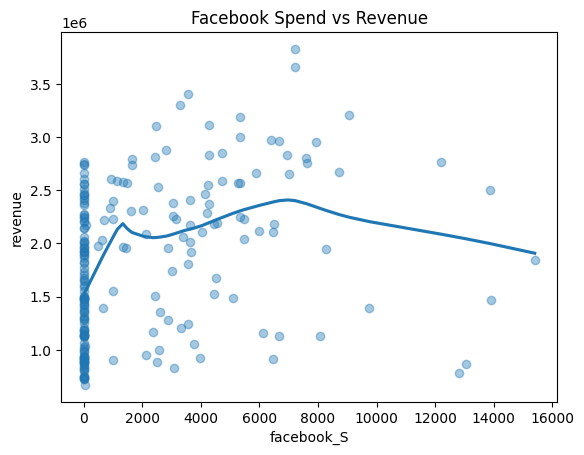

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot nonlinear relationship
sns.regplot(
    x=df["facebook_S"],
    y=df[target],
    lowess=True,
    scatter_kws={"alpha":0.4}
)

plt.title("Facebook Spend vs Revenue")

plt.show()

The relationship between Facebook spend and revenue appears
nonlinear. Revenue initially increases with higher advertising spend,
but the marginal gains weaken at larger spending levels, indicating
potential diminishing returns. This behavior motivates the inclusion
of nonlinear saturation transformations in the Bayesian MMM
specification.